In [1]:
import pandas as pd, numpy as np, ast

# --- tool scores + variant type (training-annotated reference) ---
onco = pd.read_csv("exonic_toolscores_oncokb_apicall.txt", sep="\t", low_memory=False)
onco = onco[onco["ANNOTATED"] == True]

tool_cols = ["VEST4_score","REVEL_score","MutPred_score","PrimateAI_score",
             "VARITY_R_score","VARITY_ER_score","ESM1b_score","EVE_score","AlphaMissense_score"]
for c in tool_cols:
    onco[c] = pd.to_numeric(onco[c], errors="coerce")

# --- LOFTEE calls for the indel arm ---
lof = pd.read_csv("sites_biallelic_exome.indels.vep112_loftee.plof_calls.tsv",
                  sep="\t", low_memory=False)
lof1 = lof[lof["mane_select"] != "."].drop_duplicates("variant_id").copy()

def vcf_to_annovar(pos, ref, alt):
    pos, ref, alt = int(pos), str(ref), str(alt)
    if len(ref) > len(alt):
        return pos + len(alt), ref[len(alt):], "-"
    elif len(alt) > len(ref):
        return pos + len(ref) - 1, "-", alt[len(ref):]
    return pos, ref, alt

conv = lof1.apply(lambda r: vcf_to_annovar(r["pos"], r["ref"], r["alt"]), axis=1)
lof1["Chr"] = lof1["chrom"]
lof1[["Start","Ref","Alt"]] = pd.DataFrame(conv.tolist(), index=lof1.index)
loftee = lof1[["Chr","Start","Ref","Alt","loftee_lof"]]

# --- population-enriched variants ---
fisher = pd.read_csv("fisher_enrichment_results.tsv.gz", sep="\t", low_memory=False)
fisher["Chr"] = fisher["locus"].str.split(":").str[0]
fisher["Start"] = fisher["locus"].str.split(":").str[1].astype(int)
parsed = fisher["alleles"].apply(ast.literal_eval)
fisher["Ref"] = parsed.str[0]
fisher["Alt"] = parsed.str[1]

print("annotated:", len(onco), "| loftee:", len(loftee),
      "| fisher unique:", fisher[["Chr","Start","Ref","Alt"]].drop_duplicates().shape[0])

annotated: 169360 | loftee: 7056 | fisher unique: 109471


In [2]:
# 1. Unique variants only (Fisher rows repeat across populations/comparisons)
fvar = fisher[["Chr","Start","Ref","Alt"]].drop_duplicates().copy()

# 2. Flag indels -- only these need notation conversion
r = fvar["Ref"].astype(str); a = fvar["Alt"].astype(str)
fvar["is_indel"] = (r.str.len() != a.str.len())
print("unique fisher variants:", len(fvar))
print("  SNVs:", int((~fvar["is_indel"]).sum()), "| indels:", int(fvar["is_indel"].sum()))

# 3. Merge against the annotated data
keep = ["Chr","Start","Ref","Alt","Gene.refGeneWithVer","Func.refGeneWithVer",
        "ExonicFunc.refGeneWithVer","ONCOGENIC"] + tool_cols
m = fvar.merge(onco[keep], on=["Chr","Start","Ref","Alt"], how="left")

# 4. Match rate, split by variant type
m["matched"] = m["ExonicFunc.refGeneWithVer"].notna()
print("\nmatched overall:", int(m["matched"].sum()), "of", len(m))
print(m.groupby("is_indel")["matched"].agg(["sum","count","mean"]).round(3))

# 5. Variant types among the matched
print("\nvariant types among matched:")
print(m.loc[m["matched"], "ExonicFunc.refGeneWithVer"].value_counts())

unique fisher variants: 109471
  SNVs: 108726 | indels: 745

matched overall: 14622 of 109471
            sum   count   mean
is_indel                      
False     14622  108726  0.134
True          0     745  0.000

variant types among matched:
ExonicFunc.refGeneWithVer
nonsynonymous SNV    13926
stopgain               554
synonymous SNV          99
startloss               42
stoploss                 1
Name: count, dtype: int64


In [3]:
# Apply the same VCF -> ANNOVAR conversion used for LOFTEE
fvar_conv = fvar.copy()
idx = fvar_conv["is_indel"]

conv = fvar_conv.loc[idx].apply(
    lambda r: vcf_to_annovar(r["Start"], r["Ref"], r["Alt"]), axis=1)
fvar_conv.loc[idx, ["Start","Ref","Alt"]] = pd.DataFrame(
    conv.tolist(), index=conv.index, columns=["Start","Ref","Alt"])

# Re-merge with converted coordinates
m2 = fvar_conv.merge(onco[keep], on=["Chr","Start","Ref","Alt"], how="left")
m2["matched"] = m2["ExonicFunc.refGeneWithVer"].notna()

print("after conversion:")
print(m2.groupby("is_indel")["matched"].agg(["sum","count","mean"]).round(3))
print("\nvariant types among matched:")
print(m2.loc[m2["matched"], "ExonicFunc.refGeneWithVer"].value_counts())

after conversion:
            sum   count   mean
is_indel                      
False     14622  108726  0.134
True        444     745  0.596

variant types among matched:
ExonicFunc.refGeneWithVer
nonsynonymous SNV          13926
stopgain                     586
frameshift deletion          279
frameshift insertion         114
synonymous SNV                99
startloss                     42
nonframeshift deletion        17
nonframeshift insertion        2
stoploss                       1
Name: count, dtype: int64


In [4]:
m3 = m2.merge(loftee, on=["Chr","Start","Ref","Alt"], how="left")

lof_types = ["frameshift deletion","frameshift insertion","stopgain","startloss","stoploss"]
sub = m3[m3["ExonicFunc.refGeneWithVer"].isin(lof_types)]

print("LOFTEE coverage by variant type:")
print(sub.groupby("ExonicFunc.refGeneWithVer")["loftee_lof"]
         .agg(n="size", with_call=lambda s: s.notna().sum(),
              hc=lambda s: (s == "HC").sum()))

LOFTEE coverage by variant type:
                             n  with_call   hc
ExonicFunc.refGeneWithVer                     
frameshift deletion        279        279  270
frameshift insertion       114        114  113
startloss                   42          0    0
stopgain                   586         31   30
stoploss                     1          0    0


In [5]:
res = m3.copy()

# --- 1. Assign a route to every variant ---
def assign_route(row):
    if pd.notna(row.get("loftee_lof")):
        return "loftee"                 # has a LOFTEE call
    et = row["ExonicFunc.refGeneWithVer"]
    if et == "nonsynonymous SNV":
        return "model"                  # missense -> ensemble
    if et == "stopgain":
        return "rule_lof"               # truncating, no LOFTEE call
    if pd.isna(et):
        return "unmatched"              # synonymous, in-frame, startloss, stoploss
    return "no_prediction"

res["route"] = res.apply(assign_route, axis=1)

# --- 2. Fill in the non-model arms ---
res["call"] = np.nan
res.loc[res["route"]=="loftee", "call"] = (
    res.loc[res["route"] == "loftee", "loftee_lof"].eq("HC").astype(int))
res.loc[res["route"] == "rule_lof", "call"] = 1          # stopgain treated as LoF

res["route"].value_counts()

route
unmatched        94393
model            13926
rule_lof           555
loftee             437
no_prediction      160
Name: count, dtype: int64

In [6]:
# Features the model consumes. VARITY_ER dropped (0.95 correlated with VARITY_R).

MODEL_TOOLS = ["VEST4_score","REVEL_score","MutPred_score","PrimateAI_score",
               "VARITY_R_score","ESM1b_score","EVE_score","AlphaMissense_score"]

model_arm = res[res["route"] == "model"]
print("missense variants routed to model:", len(model_arm))
print("  with ALL tools present:", int(model_arm[MODEL_TOOLS].notna().all(axis=1).sum()))
print("  with at least one missing:", int(model_arm[MODEL_TOOLS].isna().any(axis=1).sum()))
print("\nmissing per tool:")
print(model_arm[MODEL_TOOLS].isna().sum().sort_values(ascending=False))

missense variants routed to model: 13926
  with ALL tools present: 5467
  with at least one missing: 8459

missing per tool:
EVE_score              5421
MutPred_score          4783
VARITY_R_score          523
ESM1b_score             482
REVEL_score             278
PrimateAI_score         260
AlphaMissense_score     112
VEST4_score               3
dtype: int64


# Model Training

In [7]:
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, roc_curve

# Training labels: oncoKB posities, OnvoKB neutral + Clinvar Benign
clinvar = pd.read_csv("hersh_exome_biallelic_annovar_annotated.hg38_multianno.missense_ref_alt_chrom_position_gene_clinvar.tsv",
                      sep="\t", low_memory=False)
clv = clinvar[["Chrom","Position","Ref","Alt","ClinVar_CLNSIG"]].rename(
        columns={"Chrom":"Chr","Position":"Start"})
train = onco.merge(clv, on=["Chr","Start","Ref","Alt"], how="left")

benign = ["Benign","Likely_benign","Benign/Likely_benign"]
pos = train["ONCOGENIC"].isin(["Oncogenic","Likely Oncogenic"])
neg = (train["ONCOGENIC"] == "Likely Neutral") | (train["ClinVar_CLNSIG"].isin(benign))
missense = train["ExonicFunc.refGeneWithVer"] == "nonsynonymous SNV"


lab = train[missense & (pos | neg)].copy()
lab["label"] = pos[lab.index].astype(int)
print("training set:", len(lab),
      "| pos:", int(lab["label"].sum()), "| neg:", int((lab["label"] == 0).sum()))


# --- Fit ---
X = lab[MODEL_TOOLS].values          # NaNs retained; HGB handles them natively
y = lab["label"].values

cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
hgb = HistGradientBoostingClassifier(random_state=0)

proba_cv = cross_val_predict(hgb, X, y, cv=cv, method="predict_proba")[:, 1]
print("CV AUROC:", round(roc_auc_score(y, proba_cv), 3))

fpr, tpr, thr = roc_curve(y, proba_cv)
THRESHOLD = float(thr[(tpr - fpr).argmax()])
print("Youden threshold:", round(THRESHOLD, 4))

final_model = hgb.fit(X, y)

training set: 3575 | pos: 824 | neg: 2751
CV AUROC: 0.898
Youden threshold: 0.1397


In [8]:
print("label conflicts (pos AND neg):", int((pos & neg & missense).sum()))

from_oncokb  = missense & neg & (train["ONCOGENIC"] == "Likely Neutral")
from_clinvar = missense & neg & train["ClinVar_CLNSIG"].isin(benign) & ~(train["ONCOGENIC"] == "Likely Neutral")
print("negatives from OncoKB Likely Neutral:", int(from_oncokb.sum()))
print("negatives from ClinVar benign only  :", int(from_clinvar.sum()))

print("duplicate variant keys in lab:",
      int(lab[["Chr","Start","Ref","Alt"]].duplicated().sum()))

label conflicts (pos AND neg): 46
negatives from OncoKB Likely Neutral: 219
negatives from ClinVar benign only  : 2578
duplicate variant keys in lab: 0


In [9]:
# HGB on everything vs random forest on complete cases only
comp_mask = model_arm[MODEL_TOOLS].notna().all(axis=1)

p_hgb = final_model.predict_proba(model_arm[MODEL_TOOLS].values)[:, 1]

rf = RandomForestClassifier(n_estimators=500, class_weight="balanced", random_state=0)
rf.fit(lab.dropna(subset=MODEL_TOOLS)[MODEL_TOOLS].values,
       lab.dropna(subset=MODEL_TOOLS)["label"].values)
p_rf = rf.predict_proba(model_arm.loc[comp_mask, MODEL_TOOLS].values)[:, 1]

print("variants both models can score:", int(comp_mask.sum()))
print("correlation of predictions:", round(np.corrcoef(p_hgb[comp_mask.values], p_rf)[0,1], 3))
print("variants only HGB can score:", int((~comp_mask).sum()))

variants both models can score: 5467
correlation of predictions: 0.912
variants only HGB can score: 8459


In [10]:
mask_model = res["route"] == "model"

X_score = res.loc[mask_model, MODEL_TOOLS].values
res.loc[mask_model, "probability"] = final_model.predict_proba(X_score)[:, 1]
res.loc[mask_model, "call"] = (res.loc[mask_model, "probability"] >= THRESHOLD).astype(int)

res["n_tools"] = np.nan
res.loc[mask_model, "n_tools"] = res.loc[mask_model, MODEL_TOOLS].notna().sum(axis=1)

print(res.groupby("route")["call"].agg(n="size", called="sum", rate="mean").round(3))
print()
print(res.loc[mask_model, "probability"].describe().round(3))

                   n  called   rate
route                              
loftee           437   426.0  0.975
model          13926  7394.0  0.531
no_prediction    160     0.0    NaN
rule_lof         555   555.0  1.000
unmatched      94393     0.0    NaN

count    13926.000
mean         0.287
std          0.294
min          0.000
25%          0.035
50%          0.166
75%          0.495
max          0.998
Name: probability, dtype: float64


In [11]:
key = ["Chr","Start","Ref","Alt"]

# 1. duplicate variants in the training set (would double-count and split across CV folds)
print("duplicate keys in lab:", int(lab[key].duplicated().sum()))

# 2. scored variants the model was also trained on (in-sample = optimistic)
oof_map = dict(zip(map(tuple, lab[key].values), proba_cv))
mkeys   = list(map(tuple, res.loc[mask_model, key].values))
in_train = np.array([k in oof_map for k in mkeys])
print("model-route variants also in training:", int(in_train.sum()), "of", len(mkeys))

# 3. label conflicts -- OncoKB oncogenic AND ClinVar benign
print("label conflicts (pos & neg):", int((pos & neg & missense).sum()))

# 4. variants routed to loftee that are not LoF types
stray = res[(res["route"]=="loftee") & ~res["ExonicFunc.refGeneWithVer"].isin(lof_types)]
print("\nstray loftee routes:", len(stray))
print(stray["ExonicFunc.refGeneWithVer"].fillna("(unmatched)").value_counts())

# 5. negatives: how many come from ClinVar rather than OncoKB
from_oncokb = missense & neg & (train["ONCOGENIC"] == "Likely Neutral")
print("\nnegatives from OncoKB Likely Neutral:", int(from_oncokb.sum()))
print("negatives from ClinVar benign only  :", int((missense & neg & ~from_oncokb).sum()))

duplicate keys in lab: 0
model-route variants also in training: 269 of 13926
label conflicts (pos & neg): 46

stray loftee routes: 13
ExonicFunc.refGeneWithVer
(unmatched)               12
nonframeshift deletion     1
Name: count, dtype: int64

negatives from OncoKB Likely Neutral: 219
negatives from ClinVar benign only  : 2578


In [12]:
before = res.loc[mask_model, "probability"].values.copy()
p = before.copy()
p[in_train] = [oof_map[k] for k, f in zip(mkeys, in_train) if f]

# how much did the swapped 269 move?
d = pd.DataFrame({"in_sample": before[in_train], "out_of_fold": p[in_train]})
print("the", int(in_train.sum()), "swapped variants:")
print(d.describe().round(3))
print("\nmean shift:", round((d["out_of_fold"] - d["in_sample"]).mean(), 4))
print("calls that flipped:",
      int(((before[in_train] >= THRESHOLD) != (p[in_train] >= THRESHOLD)).sum()))

res.loc[mask_model, "probability"] = p
res.loc[mask_model, "in_training"]  = in_train.astype(int)
res.loc[mask_model, "call"]         = (p >= THRESHOLD).astype(int)

print("\ntotal called oncogenic:", int(res.loc[mask_model, "call"].sum()),
      f"({res.loc[mask_model,'call'].mean():.1%} of the missense arm)")

the 269 swapped variants:
       in_sample  out_of_fold
count    269.000      269.000
mean       0.543        0.421
std        0.364        0.364
min        0.001        0.000
25%        0.167        0.077
50%        0.667        0.332
75%        0.885        0.788
max        0.996        0.999

mean shift: -0.1229
calls that flipped: 44

total called oncogenic: 7370 (52.9% of the missense arm)


In [13]:
from sklearn.metrics import precision_recall_curve

prec, rec, t_pr = precision_recall_curve(y, proba_cv)

ok = rec[:-1] >= 0.90                      # thresholds that still catch 90% of positives
THRESH_R90 = float(t_pr[ok].max())         # of those, the strictest
i = int(np.where(t_pr == THRESH_R90)[0][0])
j = int(np.argmin(np.abs(t_pr - THRESHOLD)))

print(f"Youden    thr={THRESHOLD:.4f}   precision={prec[j]:.3f}  recall={rec[j]:.3f}")
print(f"recall-90 thr={THRESH_R90:.4f}   precision={prec[i]:.3f}  recall={rec[i]:.3f}")

rule_arms = res["route"].isin(["rule_lof", "loftee"])
res["call_youden"] = res["call"]
res.loc[mask_model, "call_recall90"] = (res.loc[mask_model, "probability"] >= THRESH_R90).astype(int)
res.loc[rule_arms,  "call_recall90"] = res.loc[rule_arms, "call"]

print("\ncalled oncogenic on the missense arm:")
print("   Youden   :", int(res.loc[mask_model, "call_youden"].sum()),
      f"({res.loc[mask_model,'call_youden'].mean():.1%})")
print("   recall-90:", int(res.loc[mask_model, "call_recall90"].sum()),
      f"({res.loc[mask_model,'call_recall90'].mean():.1%})")

Youden    thr=0.1397   precision=0.574  recall=0.824
recall-90 thr=0.0672   precision=0.472  recall=0.900

called oncogenic on the missense arm:
   Youden   : 7370 (52.9%)
   recall-90: 9089 (65.3%)


In [14]:
BINS, LABS = [-0.1, 3, 5, 7, 8], ["1-3", "4-5", "6-7", "8"]
n_lab = lab[MODEL_TOOLS].notna().sum(axis=1)

# 1. is the training population shaped like the population being scored?
dist = pd.DataFrame({
    "training":        pd.cut(n_lab, BINS, labels=LABS).value_counts(normalize=True),
    "fisher_missense": pd.cut(res.loc[mask_model, "n_tools"], BINS, labels=LABS).value_counts(normalize=True),
}).sort_index().round(3)
print("share of variants by tool coverage:")
display(dist)

# 2. out-of-fold accuracy within each coverage stratum
tmp = pd.DataFrame({"y": y, "p": proba_cv, "s": pd.cut(n_lab, BINS, labels=LABS).values})
out = []
for s, g in tmp.groupby("s", observed=True):
    out.append({"n_tools": s, "n": len(g), "pos_rate": round(g["y"].mean(), 3),
                "oof_auroc": round(roc_auc_score(g["y"], g["p"]), 3) if g["y"].nunique() > 1 else None})
print("\nout-of-fold AUROC by coverage:")
display(pd.DataFrame(out))

# 3. how the Fisher calls actually distribute
print("\ncalls on the Fisher missense arm:")
display(res[mask_model].groupby("n_tools").agg(
    n=("call_youden", "size"),
    youden=("call_youden", "mean"),
    recall90=("call_recall90", "mean")).round(3))

share of variants by tool coverage:


,training,fisher_missense
1-3,0.031,0.003
4-5,0.134,0.040
6-7,0.464,0.564
8,0.370,0.393



out-of-fold AUROC by coverage:


,n_tools,n,pos_rate,oof_auroc
0,1-3,111,0.099,0.532
1,4-5,480,0.206,0.845
2,6-7,1660,0.104,0.863
3,8,1324,0.409,0.886



calls on the Fisher missense arm:


,n,youden,recall90
n_tools,,,
0.0,1,0.000,1.000
2.0,1,0.000,1.000
3.0,41,0.049,0.122
4.0,145,0.159,0.372
5.0,418,0.567,0.727
6.0,1956,0.246,0.365
7.0,5897,0.463,0.600
8.0,5467,0.713,0.817


In [15]:
print("call rate on TRAINING at Youden:", round((proba_cv >= THRESHOLD).mean(), 3))
print("call rate on FISHER   at Youden:", round(res.loc[mask_model, "call_youden"].mean(), 3))

call rate on TRAINING at Youden: 0.331
call rate on FISHER   at Youden: 0.529


In [16]:
print("AUROC of tool coverage alone:",
      round(roc_auc_score(y, lab[MODEL_TOOLS].notna().sum(axis=1)), 3))

AUROC of tool coverage alone: 0.682


In [17]:
res.loc[mask_model & (res["n_tools"] < 4), "low_confidence"] = 1
res.loc[mask_model & (res["n_tools"] == 0), "route"] = "no_prediction"

In [18]:
sub = res[mask_model].copy()
sub["pattern"] = sub[MODEL_TOOLS].notna().apply(
    lambda r: "".join("1" if v else "0" for v in r), axis=1)
display(sub.groupby("pattern").agg(n=("call_youden","size"), rate=("call_youden","mean"))
          .query("n >= 100").sort_values("rate", ascending=False).round(3))

,n,rate
pattern,,
11110001,295,0.742
11111111,5467,0.713
11101101,130,0.708
11111101,3159,0.586
11011111,2671,0.306
11011101,1523,0.211
10011111,257,0.202
11010001,132,0.159


In [19]:
print(f"{'tool':22s} {'coverage':>9} {'pos|present':>12} {'pos|missing':>12} {'AUROC':>7}")
for t in MODEL_TOOLS:
    obs = lab[t].notna().values
    if obs.all() or not obs.any():
        print(f"{t:22s} {obs.mean():9.3f}  {'(always present)':>25}")
        continue
    print(f"{t:22s} {obs.mean():9.3f} {y[obs].mean():12.3f} {y[~obs].mean():12.3f} "
          f"{roc_auc_score(y, obs.astype(int)):7.3f}")

# and the same missingness-pattern table on the labeled side
subl = lab.copy()
subl["pattern"] = subl[MODEL_TOOLS].notna().astype(int).astype(str).agg("".join, axis=1)
display(subl.groupby("pattern").agg(n=("label","size"), pos_rate=("label","mean"))
            .query("n >= 50").sort_values("pos_rate", ascending=False).round(3))

tool                    coverage  pos|present  pos|missing   AUROC
VEST4_score                0.977        0.233        0.122   0.507
REVEL_score                0.959        0.237        0.075   0.518
MutPred_score              0.568        0.348        0.076   0.688
PrimateAI_score            0.934        0.237        0.139   0.517
VARITY_R_score             0.839        0.238        0.191   0.518
ESM1b_score                0.867        0.237        0.186   0.517
EVE_score                  0.610        0.284        0.147   0.592
AlphaMissense_score        0.977        0.233        0.119   0.507


,n,pos_rate
pattern,,
11111111,1324,0.409
11110001,214,0.327
11100101,70,0.286
11111101,395,0.192
00000000,81,0.123
11011111,816,0.096
11011101,389,0.049
11010001,145,0.048


Note: you may need to restart the kernel to use updated packages.
TreeExplainer additivity: pass
SHAP matrix: (3575, 8)


,tool,clinvar_trained,coverage,mean_abs_shap,when_observed,signed_when_missing
0,VARITY_R_score,True,0.839,0.7970,0.8987,0.2430
1,MutPred_score,True,0.568,0.8381,0.7897,-0.9018
2,AlphaMissense_score,False,0.977,0.4937,0.5047,0.0101
3,REVEL_score,True,0.959,0.4840,0.4966,-0.1225
4,VEST4_score,True,0.977,0.4189,0.4105,0.7777
5,ESM1b_score,False,0.867,0.3749,0.4042,-0.0099
6,PrimateAI_score,False,0.934,0.2932,0.2862,0.3777
7,EVE_score,False,0.610,0.2115,0.2591,-0.1177


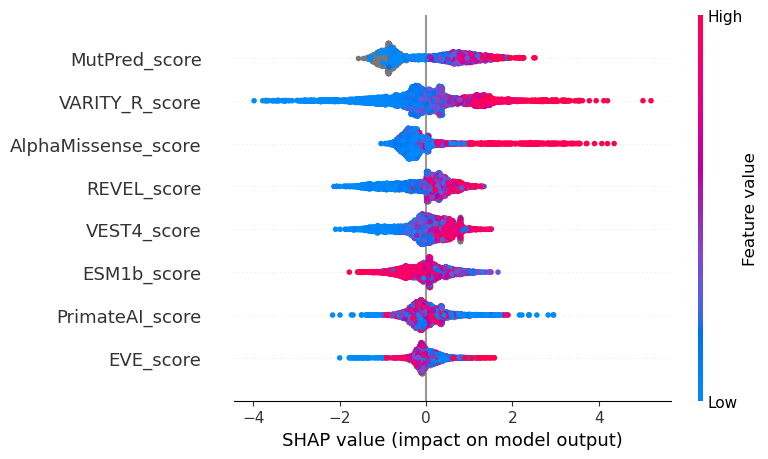

In [23]:
%pip install shap -q
import shap, matplotlib.pyplot as plt, os

X_TRAIN = lab[MODEL_TOOLS]        # DataFrame, not X -- SHAP needs the column names

def additivity_ok(sv, Xd, mdl, tol=1e-3):
    recon = sv.values.sum(axis=1) + np.asarray(sv.base_values).reshape(-1)
    return np.max(np.abs(recon - mdl.decision_function(Xd.values))) < tol

sv, ok = None, False
try:
    explainer = shap.TreeExplainer(final_model)
    sv = explainer(X_TRAIN)
    ok = additivity_ok(sv, X_TRAIN, final_model)
    print("TreeExplainer additivity:", "pass" if ok else "FAIL")
except Exception as e:
    print("TreeExplainer failed:", e)

if not ok:
    print("falling back to Permutation explainer (NaN-safe, slower)")
    bg = shap.sample(X_TRAIN, 200, random_state=0)
    explainer = shap.explainers.Permutation(
        lambda A: final_model.decision_function(A), bg)
    sv = explainer(X_TRAIN, max_evals=2 * len(MODEL_TOOLS) + 1)

S = sv.values
print("SHAP matrix:", S.shape)

# ---- importance table ----
CLINVAR_TRAINED = {"VARITY_R_score", "REVEL_score", "VEST4_score", "MutPred_score"}
rows = []
for j, t in enumerate(MODEL_TOOLS):
    obs = X_TRAIN[t].notna().values
    rows.append({
        "tool": t,
        "clinvar_trained": t in CLINVAR_TRAINED,
        "coverage": round(obs.mean(), 3),
        "mean_abs_shap": round(np.abs(S[:, j]).mean(), 4),
        "when_observed": round(np.abs(S[obs, j]).mean(), 4) if obs.any() else None,
        "signed_when_missing": round(S[~obs, j].mean(), 4) if (~obs).any() else None,
    })
imp = pd.DataFrame(rows).sort_values("when_observed", ascending=False, ignore_index=True)
display(imp)

# ---- summary plot ----
os.makedirs("figures", exist_ok=True)
shap.summary_plot(S, X_TRAIN, feature_names=MODEL_TOOLS, show=False)
plt.tight_layout()
plt.savefig("figures/shap_summary_missense.png", dpi=200, bbox_inches="tight")
plt.show()

In [24]:
sv_pred = explainer(res.loc[mask_model, MODEL_TOOLS])
P       = sv_pred.values
base_p  = np.asarray(sv_pred.base_values).reshape(-1)

# same additivity guarantee, now on the scored set
err = np.max(np.abs(base_p + P.sum(1) -
                    final_model.decision_function(res.loc[mask_model, MODEL_TOOLS].values)))
print("additivity on the Fisher arm, max error:", f"{err:.2e}")

tools = np.array(MODEL_TOOLS)
res.loc[mask_model, "top_driver"]      = tools[np.argmax(P, axis=1)]   # hardest push -> oncogenic
res.loc[mask_model, "top_driver_shap"] = P.max(axis=1).round(4)
res.loc[mask_model, "top_brake"]       = tools[np.argmin(P, axis=1)]   # hardest push -> benign

print("\ntop driver among variants CALLED oncogenic (Youden):")
display(res.loc[mask_model & (res["call_youden"] == 1), "top_driver"].value_counts())

print("\nstrongest push toward benign, whole missense arm:")
display(res.loc[mask_model, "top_brake"].value_counts())

# is that benign push coming from a low MutPred score, or from MutPred not running?
mp = mask_model & (res["top_brake"] == "MutPred_score")
print("\nvariants whose strongest benign push is MutPred:", int(mp.sum()))
print("   of those, MutPred is MISSING in:", int((mp & res["MutPred_score"].isna()).sum()))

additivity on the Fisher arm, max error: 1.69e-14

top driver among variants CALLED oncogenic (Youden):


top_driver
VARITY_R_score         3433
MutPred_score          2663
AlphaMissense_score     638
ESM1b_score             316
VEST4_score             199
REVEL_score              55
PrimateAI_score          34
EVE_score                32
Name: count, dtype: int64


strongest push toward benign, whole missense arm:


top_brake
MutPred_score          4454
AlphaMissense_score    3305
PrimateAI_score        1824
ESM1b_score            1266
REVEL_score            1199
EVE_score               909
VARITY_R_score          747
VEST4_score             222
Name: count, dtype: int64


variants whose strongest benign push is MutPred: 4454
   of those, MutPred is MISSING in: 4253


In [25]:
print(list(fisher.columns))

['locus', 'alleles', 'focal_pop', 'comparison', 'carriers_focal', 'total_focal', 'carriers_ref', 'total_ref', 'odds_ratio', 'p_value', 'p_adjusted', 'Chr', 'Start', 'Ref', 'Alt']


In [ ]:
ENR_POP, ENR_CMP = "focal_pop", "comparison"
ENR_OR,  ENR_P   = "odds_ratio", "p_adjusted"
gk = ["Chr", "Start", "Ref", "Alt"]

# --- 1. map VCF coords (fisher) -> ANNOVAR coords (res) -----------------------
kmap = (fisher[gk].drop_duplicates()
          .rename(columns={"Start": "Start_o", "Ref": "Ref_o", "Alt": "Alt_o"})
          .reset_index(drop=True))
ind  = kmap["Ref_o"].astype(str).str.len() != kmap["Alt_o"].astype(str).str.len()
conv = kmap.loc[ind].apply(lambda x: vcf_to_annovar(x["Start_o"], x["Ref_o"], x["Alt_o"]), axis=1)
kmap[["Start", "Ref", "Alt"]] = kmap[["Start_o", "Ref_o", "Alt_o"]].values
kmap.loc[ind, ["Start", "Ref", "Alt"]] = pd.DataFrame(
    conv.tolist(), index=conv.index, columns=["Start", "Ref", "Alt"])
kmap["Start"] = kmap["Start"].astype(int)
print("key map:", kmap.shape, "| indels converted:", int(ind.sum()))

# --- 2. collapse enrichment to one row per variant ---------------------------
f = fisher.sort_values(ENR_P)
enr = (f.groupby(gk, as_index=False)
         .agg(top_focal_pop=(ENR_POP, "first"), top_comparison=(ENR_CMP, "first"),
              top_odds_ratio=(ENR_OR, "first"), min_p_adjusted=(ENR_P, "first"),
              n_tests=(ENR_P, "size"),
              n_sig_tests=(ENR_P, lambda s: int((s < 0.05).sum()))))
sig = (f[f[ENR_P] < 0.05].groupby(gk)[ENR_POP]
         .agg(lambda s: ";".join(sorted(set(s.astype(str)))))
         .rename("enriched_pops").reset_index())
enr = (enr.merge(sig, on=gk, how="left")
          .rename(columns={"Start": "Start_o", "Ref": "Ref_o", "Alt": "Alt_o"}))

# --- 3. attach predictions on the converted key ------------------------------
pred_cols = gk + ["Gene.refGeneWithVer", "ExonicFunc.refGeneWithVer", "route",
                  "probability", "n_tools", "low_confidence", "in_training",
                  "call_youden", "call_recall90",
                  "top_driver", "top_driver_shap", "top_brake"]
pred_cols = [c for c in pred_cols if c in res.columns]

final = (enr.merge(kmap, on=["Chr", "Start_o", "Ref_o", "Alt_o"], how="left")
            .merge(res[pred_cols], on=gk, how="left"))
final["route"] = final["route"].fillna("unmatched")
for c in ["call_youden", "call_recall90", "low_confidence", "in_training", "n_tools"]:
    if c in final.columns:
        final[c] = final[c].astype("Int64")

final = final.rename(columns={"Start_o": "Start", "Ref_o": "Ref", "Alt_o": "Alt",
                              "Start": "Start_annovar", "Ref": "Ref_annovar",
                              "Alt": "Alt_annovar"})
front = [c for c in ["Chr","Start","Ref","Alt","Gene.refGeneWithVer",
                     "ExonicFunc.refGeneWithVer","route","probability",
                     "call_youden","call_recall90","n_tools","low_confidence"]
         if c in final.columns]
final = final[front + [c for c in final.columns if c not in front]]

# --- 4. verify before writing ------------------------------------------------
assert len(final) == 109471, f"row count changed: {len(final)}"
assert final[["Chr","Start","Ref","Alt"]].duplicated().sum() == 0, "duplicate variants"
print("\n", final.groupby("route").size(), sep="")
is_ind = final["Ref"].astype(str).str.len() != final["Alt"].astype(str).str.len()
print("\nindels:", int(is_ind.sum()),
      "| with a call:", int(final.loc[is_ind, "call_youden"].notna().sum()), "(expect ~444)")
print("total with a call :", int(final["call_youden"].notna().sum()), "(expect ~14,917)")
print("with a probability:", int(final["probability"].notna().sum()), "(expect ~13,925)")

final.to_csv("fisher_predictions.tsv.gz", sep="\t", index=False, compression="gzip")
print("\nwrote fisher_predictions.tsv.gz", final.shape)
display(final.head(20))

key map: (109471, 7) | indels converted: 745

route
loftee             437
model            13925
no_prediction      161
rule_lof           555
unmatched        94393
dtype: int64

indels: 745 | with a call: 438 (expect ~444)
total with a call : 14918 (expect ~14,917)
with a probability: 13926 (expect ~13,925)

wrote fisher_predictions.tsv.gz (109471, 26)


,Chr,Start,Ref,Alt,Gene.refGeneWithVer,ExonicFunc.refGeneWithVer,route,probability,call_youden,call_recall90,...,n_tests,n_sig_tests,enriched_pops,Start_annovar,Ref_annovar,Alt_annovar,in_training,top_driver,top_driver_shap,top_brake
0,chr1,2228767,A,C,NaN,NaN,unmatched,NaN,<NA>,<NA>,...,9,0,NaN,2228767,A,C,<NA>,NaN,NaN,NaN
1,chr1,2228768,T,G,NaN,NaN,unmatched,NaN,<NA>,<NA>,...,7,1,Non Jew European,2228768,T,G,<NA>,NaN,NaN,NaN
2,chr1,2228771,A,C,NaN,NaN,unmatched,NaN,<NA>,<NA>,...,3,0,NaN,2228771,A,C,<NA>,NaN,NaN,NaN
